<a href="https://colab.research.google.com/github/NeevWadhwa-Helloworld/Machine-Learning-Projects/blob/main/Data_Augmentation_in_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Data Augmentation in Deep Learning**

In [40]:
pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-nlhniovp
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-nlhniovp
  Resolved https://github.com/tensorflow/docs to commit 0054afff57cd4a4ea5389088a89942603461ee6f
  Preparing metadata (setup.py) ... done


In [41]:
import sys
!pip install --upgrade protobuf
# Force a reload of the modules if possible, though a restart is safer
print('Protobuf upgraded. If errors persist, please go to "Runtime" -> "Restart session"')

Protobuf upgraded. If errors persist, please go to "Runtime" -> "Restart session"


In [42]:
import urllib
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers
AUTOTUNE = tf.data.experimental.AUTOTUNE
import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_datasets as tfds
import PIL.Image
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize']=(12,5)
import numpy as np

## **Download Image**

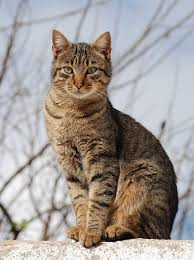

In [43]:
image_path=tf.keras.utils.get_file("cat.jpg",origin="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTIXHlIWwNlozgmkjciRkTxQkh82HHLZLTKoxKqQamEgw&s")
PIL.Image.open(image_path)

In [44]:
image_string=tf.io.read_file(image_path)
image=tf.image.decode_jpeg(image_string,channels=3)

In [45]:
def visualize(original, augmented):
  fig = plt.figure()
  plt.subplot(1, 2, 1)
  plt.title("Original Image")
  plt.imshow(original)
  plt.subplot(1, 2, 2)
  plt.title("Augmented Image")
  plt.imshow(augmented)

## **Data augmentation on a Single Image**

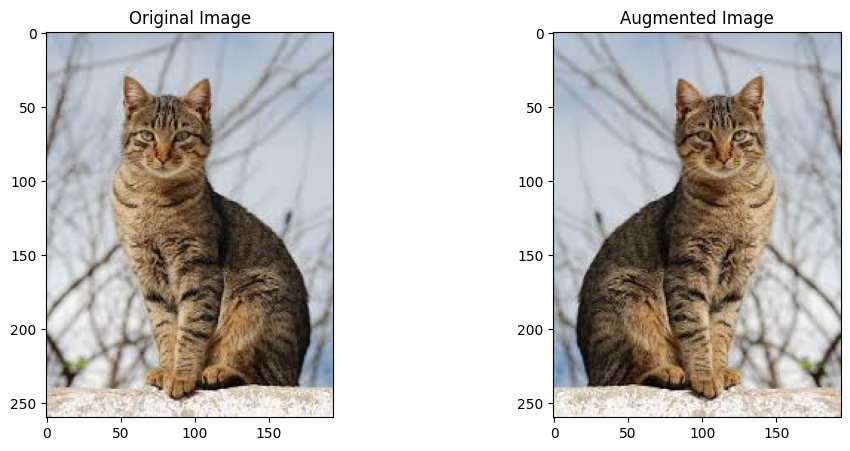

In [46]:
flipped = tf.image.flip_left_right(image)
visualize(image, flipped)

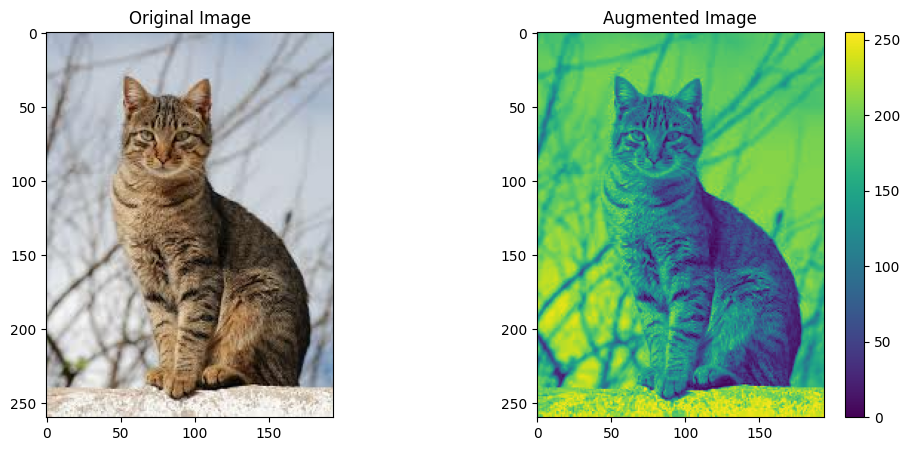

In [47]:
grayscaled = tf.image.rgb_to_grayscale(image)
visualize(image, tf.squeeze(grayscaled))
plt.colorbar()

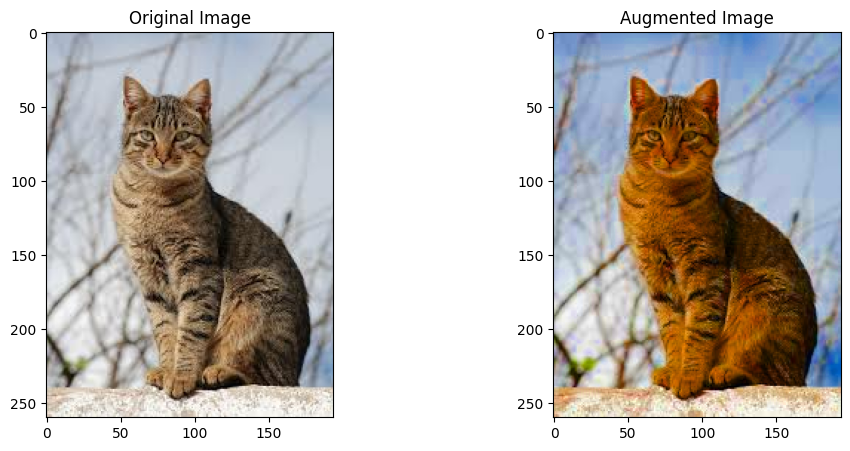

In [48]:
saturated = tf.image.adjust_saturation(image, 3)
visualize(image, saturated)

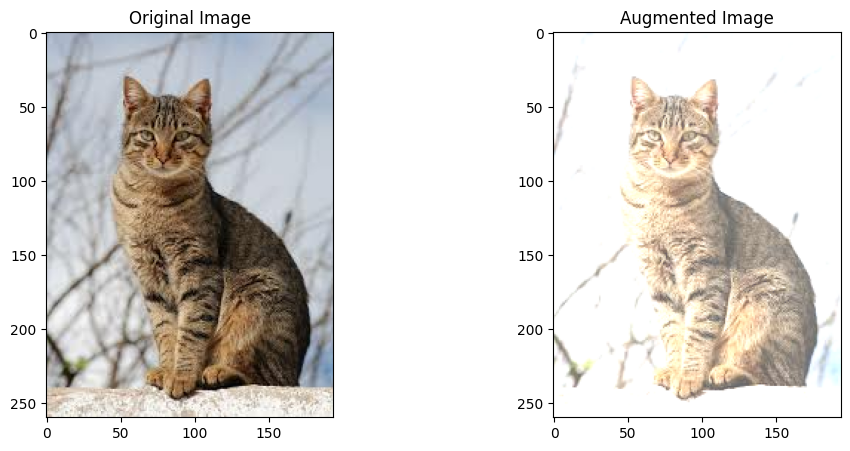

In [49]:
bright = tf.image.adjust_brightness(image, 0.4)
visualize(image, bright)

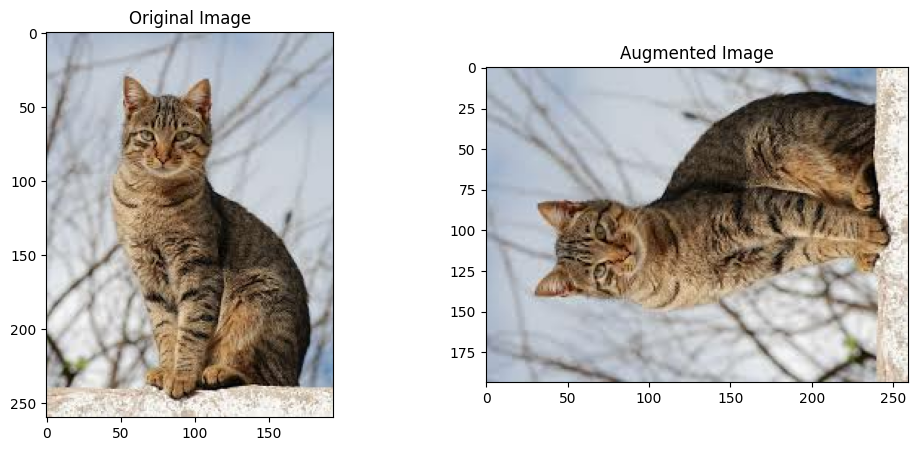

In [50]:
rotated = tf.image.rot90(image)
visualize(image, rotated)

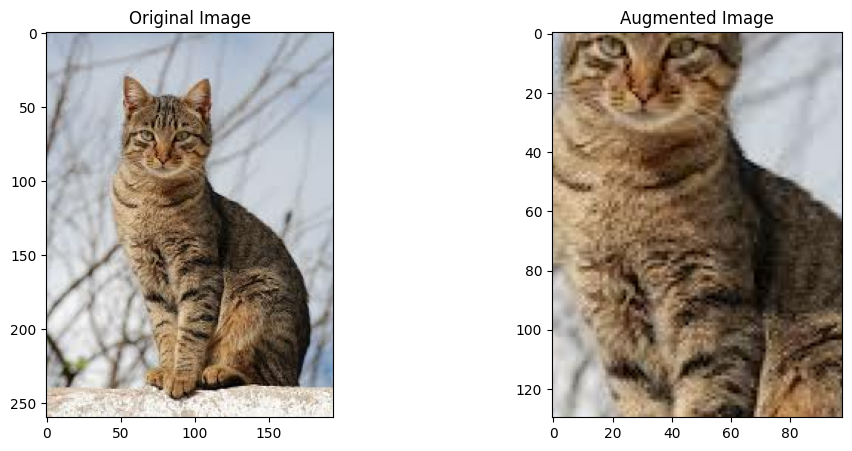

In [51]:
cropped = tf.image.central_crop(image, central_fraction=0.5)
visualize(image,cropped)

## **Data augmentation on a Dataset and Training a Model**

In [53]:
from tensorflow_datasets import load as tfds_load
import tensorflow_datasets as tfds

try:
    dataset, info = tfds_load('mnist', as_supervised=True, with_info=True)
    train_dataset, test_dataset = dataset['train'], dataset['test']
    num_train_examples = info.splits['train'].num_examples
    print(f'Successfully loaded {num_train_examples} training examples.')
except Exception as e:
    print(f'Error: {e}')
    print('Please try: Runtime > Restart session')

ImportError: cannot import name 'load' from 'tensorflow_datasets' (/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py)

In [35]:
def convert(image, label):
  image = tf.image.convert_image_dtype(image, tf.float32) # Cast and normalize the image to [0,1]
  return image, label

def augment(image,label):
  image,label = convert(image, label)
  image = tf.image.convert_image_dtype(image, tf.float32) # Cast and normalize the image to [0,1]
  image = tf.image.resize_with_crop_or_pad(image, 34, 34) # Add 6 pixels of padding
  image = tf.image.random_crop(image, size=[28, 28, 1]) # Random crop back to 28x28
  image = tf.image.random_brightness(image, max_delta=0.5) # Random brightness

  return image,label
BATCH_SIZE = 64
# Only use a subset of the data so it's easier to overfit, for this tutorial
NUM_EXAMPLES = 2048

In [36]:
augmented_train_batches = (
    train_dataset
    # Only train on a subset, so you can quickly see the effect.
    .take(NUM_EXAMPLES)
    .cache()
    .shuffle(num_train_examples//4)
    # The augmentation is added here.
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

NameError: name 'train_dataset' is not defined

In [ ]:
non_augmented_train_batches = (
    train_dataset
    # Only train on a subset, so you can quickly see the effect.
    .take(NUM_EXAMPLES)
    .cache()
    .shuffle(num_train_examples//4)
    # No augmentation.
    .map(convert, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
validation_batches = (
    test_dataset
    .map(convert, num_parallel_calls=AUTOTUNE)
    .batch(2*BATCH_SIZE)
)

In [ ]:
def make_model():
  model = tf.keras.Sequential([
      layers.Flatten(input_shape=(28, 28, 1)),
      layers.Dense(4096, activation='relu'),
      layers.Dense(4096, activation='relu'),
      layers.Dense(10)
  ])
  model.compile(optimizer = 'adam',
                loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])
  return model

## **Training Model**

In [54]:
model_without_aug = make_model()

no_aug_history = model_without_aug.fit(non_augmented_train_batches, epochs=50, validation_data=validation_batches)

NameError: name 'make_model' is not defined

In [ ]:
model_with_aug = make_model()

aug_history = model_with_aug.fit(augmented_train_batches, epochs=50, validation_data=validation_batches)

In [ ]:
plotter = tfdocs.plots.HistoryPlotter()
plotter.plot({"Augmented": aug_history, "Non-Augmented": no_aug_history}, metric = "accuracy")
plt.title("Accuracy")
plt.ylim([0.75,1])